In [77]:
from dataclasses import dataclass
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import networkx as nx
from matplotlib.lines import Line2D

In [78]:
@dataclass(frozen=True)
class Edge:
    u: object
    v: object
    p: float


class Graph:
    """Undirected multigraph with flipping probability p per edge."""

    def __init__(self):
        self.nodes = []
        self._node_set = set()
        self.edges = []

    def add_edge(self, u, v, p):
        if u == v:
            raise ValueError("Self-loops are not supported.")
        if not 0 <= p < 1:
            raise ValueError("p must lie in [0, 1).")
        for node in (u, v):
            if node not in self._node_set:
                self._node_set.add(node)
                self.nodes.append(node)
        self.edges.append(Edge(u, v, float(p)))
        return len(self.edges) - 1

    def adjacency(self):
        adj = {u: [] for u in self.nodes}
        for edge_id, edge in enumerate(self.edges):
            adj[edge.u].append((edge.v, edge_id))
            adj[edge.v].append((edge.u, edge_id))
        return adj


In [79]:
def sample_instance(graph, rng):
    """
    Sample the vertex signs sigma uniformly from {+1, -1}^n and observations

        Y_uv = sigma_u * sigma_v * Z_uv,

    where P(Z_uv = -1) = p_uv.
    """
    spins = {
        node: rng.choice((-1, 1))
        for node in graph.nodes
    }

    observations = np.empty(len(graph.edges), dtype=int)

    for edge_id, edge in enumerate(graph.edges):
        noise = -1 if rng.random() < edge.p else 1 

        observations[edge_id] = (
            spins[edge.u]
            * spins[edge.v]
            * noise
        )

    return spins, observations

## Implementation of Sum-Product BP

In [80]:
def bp_pair_estimate(
    graph,
    observations,
    source,
    target,
    max_iter=200,
    tol=1e-10,
    damping=1,
):
    """
    Approximate E[sigma_source * sigma_target | observations]
    using sum-product belief propagation.
    """
    if source == target:
        return 1.0

    adj = graph.adjacency()

    # messages[(edge_id, u, v)] is the quantity m_{u \to v}.
    messages = {}

    for edge_id, edge in enumerate(graph.edges):
        messages[edge_id, edge.u, edge.v] = 0.0
        messages[edge_id, edge.v, edge.u] = 0.0

    for _ in range(max_iter):
        new_messages = {}
        max_change = 0.0

        for edge_id, edge in enumerate(graph.edges):
            for u, v in ((edge.u, edge.v), (edge.v, edge.u)):
                key = (edge_id, u, v)

                # Fix sigma_source = +1.
                if u == source:
                    value = 1.0
                else:
                    field = 0.0

                    for neighbor, incoming_id in adj[u]:
                        if incoming_id == edge_id:
                            continue

                        incoming_edge = graph.edges[incoming_id]
                        incoming_message = messages[
                            incoming_id, neighbor, u
                        ]

                        q = 1 - 2 * incoming_edge.p

                        x = (
                            q
                            * observations[incoming_id]
                            * incoming_message
                        )
                        x = np.clip(x, -1 + 1e-15, 1 - 1e-15)

                        field += np.arctanh(x)

                    raw_value = np.tanh(field)

                    value = (
                        damping * raw_value
                        + (1 - damping) * messages[key]
                    )

                new_messages[key] = value
                max_change = max(
                    max_change,
                    abs(value - messages[key]),
                )

        messages = new_messages

        if max_change < tol:
            break

    # Compute the BP marginal at the target.
    target_field = 0.0

    for neighbor, edge_id in adj[target]:
        edge = graph.edges[edge_id]
        q = 1 - 2 * edge.p

        x = (
            q
            * observations[edge_id]
            * messages[edge_id, neighbor, target]
        )
        x = np.clip(x, -1 + 1e-15, 1 - 1e-15)

        target_field += np.arctanh(x)

    return float(np.tanh(target_field))

In [81]:
def estimate_bp_corr2(
    graph,
    source,
    target,
    n_samples=20_000,
    seed=0,
    **bp_kwargs,
):
    """
    Estimate the Corr^2 = E[X f(Y)]^2 / E[f(Y)^2] using Monte Carlo
    """
    rng = np.random.default_rng(seed)

    x_values = np.empty(n_samples)
    bp_values = np.empty(n_samples)

    for i in range(n_samples):
        spins, observations = sample_instance(graph, rng)

        x_values[i] = spins[source] * spins[target]
        bp_values[i] = bp_pair_estimate(
            graph,
            observations,
            source,
            target,
            **bp_kwargs,
        )

    # U = X f(Y), V = f(Y)^2
    u = x_values * bp_values
    v = bp_values**2

    mean_u = np.mean(u)
    mean_v = np.mean(v)

    if mean_v == 0:
        return {
            "corr2": 0.0,
            "standard_error": 0.0,
            "cross_moment": 0.0,
            "estimate_second_moment": 0.0,
        }

    corr2 = mean_u**2 / mean_v

    # Delta-method standard error for g(u, v) = u^2 / v.
    sample_covariance = np.cov(
        np.column_stack([u, v]),
        rowvar=False,
        ddof=1,
    ) / n_samples

    gradient = np.array([
        2 * mean_u / mean_v,
        -(mean_u**2) / mean_v**2,
    ])

    variance = gradient @ sample_covariance @ gradient
    standard_error = np.sqrt(max(variance, 0.0))

    return {
        "corr2": corr2,
        "standard_error": standard_error,
        "cross_moment": mean_u,
        "estimate_second_moment": mean_v,
    }

### Construct Graphs

In [82]:
def make_path(p_values):
    graph = Graph()

    for i, p in enumerate(p_values):
        graph.add_edge(i, i + 1, p)

    return graph, 0, len(p_values)


def make_cycle(p_values):
    n = len(p_values)

    if n < 3:
        raise ValueError("A cycle must have at least three edges.")

    graph = Graph()

    for i, p in enumerate(p_values):
        graph.add_edge(i, (i + 1) % n, p)

    return graph

## Estimate Percolation

In [83]:
def estimate_percolation_bound(
    graph,
    source,
    target,
    n_samples=50_000,
    seed=0,
):
    """
    Estimate P(source <-> target) under independent bond percolation,
    where edge e is open with probability (1 - 2 p_e)^2.
    """
    rng = np.random.default_rng(seed)
    adj = graph.adjacency()

    connected = np.empty(n_samples, dtype=float)

    for sample in range(n_samples):
        open_edges = np.array([
            rng.random() < (1 - 2 * edge.p)**2
            for edge in graph.edges
        ])

        visited = {source}
        stack = [source]

        while stack:
            u = stack.pop()

            for v, edge_id in adj[u]:
                if open_edges[edge_id] and v not in visited:
                    visited.add(v)
                    stack.append(v)

        connected[sample] = target in visited

    estimate = np.mean(connected)

    standard_error = np.sqrt(
        estimate * (1 - estimate) / n_samples
    )

    return {
        "bound": estimate,
        "standard_error": standard_error,
    }

In [84]:
def compare_bp_and_percolation(
    graph,
    source,
    target,
    n_bp_samples=1_000,
    n_percolation_samples=1_000,
    seed=0,
    **bp_kwargs,
):
    bp = estimate_bp_corr2(
        graph,
        source,
        target,
        n_samples=n_bp_samples,
        seed=seed,
        **bp_kwargs,
    )

    percolation = estimate_percolation_bound(
        graph,
        source,
        target,
        n_samples=n_percolation_samples,
        seed=seed + 1,
    )

    bp_se = bp["standard_error"]
    percolation_se = percolation["standard_error"]

    # Standard error of percolation_bound - bp_corr2.
    gap = percolation["bound"] - bp["corr2"]
    gap_se = np.sqrt(bp_se**2 + percolation_se**2)

    print(f"BP Corr^2:          {bp['corr2']:.6f} ± {2 * bp_se:.6f}")
    print(
        f"Percolation bound: {percolation['bound']:.6f} "
        f"± {2 * percolation_se:.6f}"
    )
    # print(f"Estimated gap:      {gap:.6f} ± {2 * gap_se:.6f}")

    if gap < -3 * gap_se:
        print("Warning: BP exceeds the bound by more than 3 standard errors.")

    return bp, percolation

## Graph Visualization

In [85]:
def draw_graph(
    graph,
    source,
    target,
    ax=None,
    seed=0,
    title=None,
    positions=None,
):
    if source not in graph.nodes:
        raise ValueError("The source is not in the graph.")

    if target not in graph.nodes:
        raise ValueError("The target is not in the graph.")

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))

    nx_graph = nx.MultiGraph()
    nx_graph.add_nodes_from(graph.nodes)

    for edge_id, edge in enumerate(graph.edges):
        nx_graph.add_edge(edge.u, edge.v, key=edge_id)

    if positions is None:
        positions = nx.spring_layout(nx_graph, seed=seed)

    ordinary_nodes = [
        node
        for node in graph.nodes
        if node not in {source, target}
    ]

    nx.draw_networkx_edges(
        nx_graph,
        positions,
        ax=ax,
        width=1.8,
        edge_color="gray",
    )

    nx.draw_networkx_nodes(
        nx_graph,
        positions,
        nodelist=ordinary_nodes,
        ax=ax,
        node_size=700,
        node_color="lightblue",
        edgecolors="black",
    )

    nx.draw_networkx_nodes(
        nx_graph,
        positions,
        nodelist=[source],
        ax=ax,
        node_size=850,
        node_color="mediumseagreen",
        edgecolors="black",
        linewidths=2,
    )

    nx.draw_networkx_nodes(
        nx_graph,
        positions,
        nodelist=[target],
        ax=ax,
        node_size=850,
        node_color="darkorange",
        edgecolors="black",
        linewidths=2,
    )

    nx.draw_networkx_labels(
        nx_graph,
        positions,
        ax=ax,
        font_size=10,
    )

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor="mediumseagreen",
            markeredgecolor="black",
            markersize=11,
            label=f"Source: {source}",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor="darkorange",
            markeredgecolor="black",
            markersize=11,
            label=f"Sink: {target}",
        ),
    ]

    ax.legend(
        handles=legend_handles,
        loc="best",
        frameon=False,
    )

    if title is not None:
        ax.set_title(title)

    ax.set_axis_off()
    return ax

<Axes: >

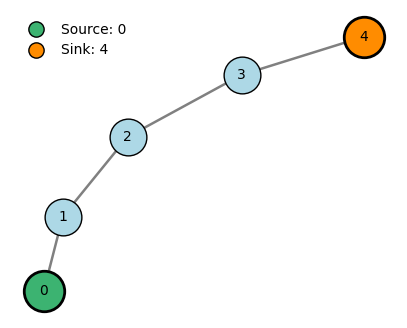

In [86]:
path, s, t = make_path([0.2, 0.2, 0.2, 0.2])
draw_graph(path, s, t)

<Axes: title={'center': 'Heterogeneous Graph'}>

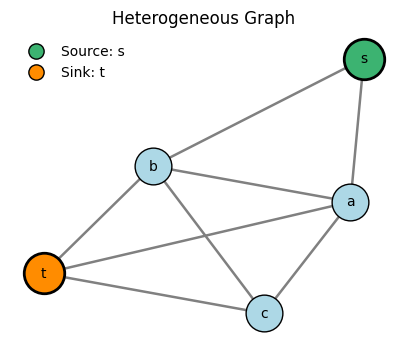

In [87]:

heterogeneous = Graph()

heterogeneous.add_edge("s", "a", 0.2)
heterogeneous.add_edge("a", "t", 0.2)

heterogeneous.add_edge("s", "b", 0.20)
heterogeneous.add_edge("b", "c", 0.2)
heterogeneous.add_edge("c", "t", 0.2)

heterogeneous.add_edge("a", "b", 0.2)
heterogeneous.add_edge("a", "c", 0.2)
heterogeneous.add_edge("b", "t", 0.2)

draw_graph(heterogeneous, "s", "t", title="Heterogeneous Graph")

# A Path Example

In [88]:
p_values = [0.2, 0.2, 0.2, 0.2]

path, s, t = make_path(p_values)

# seed = np.random.randint(0, 2**32 - 1)

compare_bp_and_percolation(
    path,
    s,
    t,
    n_bp_samples=10000,
    n_percolation_samples=1_000,
    seed=1,
)

BP Corr^2:          0.015080 ± 0.004875
Percolation bound: 0.017000 ± 0.008176


({'corr2': np.float64(0.015079840000000006),
  'standard_error': np.float64(0.0024375334925252783),
  'cross_moment': np.float64(0.015914879999999992),
  'estimate_second_moment': np.float64(0.016796159999999977)},
 {'bound': np.float64(0.017),
  'standard_error': np.float64(0.004087909000944126)})

## A heterogeneous example heoterogeous example

In [89]:
heterogeneous = Graph()

heterogeneous.add_edge("s", "a", 0.2)
heterogeneous.add_edge("a", "t", 0.2)

heterogeneous.add_edge("s", "b", 0.20)
heterogeneous.add_edge("b", "c", 0.2)
heterogeneous.add_edge("c", "t", 0.2)

heterogeneous.add_edge("a", "b", 0.2)
heterogeneous.add_edge("a", "c", 0.2)
heterogeneous.add_edge("b", "t", 0.2)

compare_bp_and_percolation(
    heterogeneous,
    "s",
    "t",
    n_bp_samples=2_000,
    n_percolation_samples=1_000,
    seed=1,
)

BP Corr^2:          0.276208 ± 0.033921
Percolation bound: 0.337000 ± 0.029895


({'corr2': np.float64(0.2762084170659332),
  'standard_error': np.float64(0.016960462545149383),
  'cross_moment': np.float64(0.29531155056306907),
  'estimate_second_moment': np.float64(0.3157358954602264)},
 {'bound': np.float64(0.337),
  'standard_error': np.float64(0.014947608504372866)})

In [90]:
def odd_boundary(graph, mask):
    """
    Return the set of odd-degree vertices in the edge subset
    represented by mask.
    """
    odd = set()

    for edge_id, edge in enumerate(graph.edges):
        if mask & (1 << edge_id):
            for node in (edge.u, edge.v):
                if node in odd:
                    odd.remove(node)
                else:
                    odd.add(node)

    return odd

In [91]:
def exact_corr2_matrix(graph, source, target):
    """
    Compute the exact Corr^2(s, t) using

        Corr^2 = c.T @ Sigma^{-1} @ c.

    The coordinates are edge subsets A satisfying
    Odd(A) = {source, target}.
    """
    if source == target:
        return {
            "corr2": 1.0,
            "corr": 1.0,
            "matrix_size": 1,
            "condition_number": 1.0,
        }

    n_edges = len(graph.edges)
    n_subsets = 1 << n_edges

    q = np.array([
        1 - 2 * edge.p
        for edge in graph.edges
    ])

    # moment[mask] = product of q_e over edges in mask
    moment = np.ones(n_subsets)

    for mask in range(1, n_subsets):
        lowest_bit = mask & -mask
        edge_id = lowest_bit.bit_length() - 1

        moment[mask] = (
            moment[mask ^ lowest_bit] * q[edge_id]
        )

    target_boundary = {source, target}

    basis_masks = [
        mask
        for mask in range(n_subsets)
        if odd_boundary(graph, mask) == target_boundary
    ]

    if not basis_masks:
        return {
            "corr2": 0.0,
            "corr": 0.0,
            "matrix_size": 0,
            "condition_number": np.inf,
        }

    # c_A = product_{e in A} q_e
    c = np.array([
        moment[mask]
        for mask in basis_masks
    ])

    # Sigma_{A,B} = product_{e in A triangle B} q_e
    Sigma = np.array([
        [
            moment[mask_a ^ mask_b]
            for mask_b in basis_masks
        ]
        for mask_a in basis_masks
    ])

    try:
        coefficients = np.linalg.solve(Sigma, c)
    except np.linalg.LinAlgError:
        # This can occur when some edges are noiseless and the
        # monomial representation becomes redundant.
        coefficients = np.linalg.pinv(
            Sigma,
            hermitian=True,
        ) @ c

    corr2 = float(c @ coefficients)

    # Remove insignificant floating-point errors.
    corr2 = float(np.clip(corr2, 0.0, 1.0))

    return {
        "corr2": corr2,
        "corr": np.sqrt(corr2),
        "matrix_size": len(basis_masks),
        "condition_number": np.linalg.cond(Sigma),
        "Sigma": Sigma,
        "c": c,
        "basis_masks": basis_masks,
    }

In [92]:
exact = exact_corr2_matrix(
    path,
    source=s,
    target=t,
)

print(f"Exact Corr^2:       {exact['corr2']:.6f}")
print(f"Exact Corr:         {exact['corr']:.6f}")
print(f"Matrix size:        {exact['matrix_size']}")
print(f"Condition number:   {exact['condition_number']:.3f}")

Exact Corr^2:       0.016796
Exact Corr:         0.129600
Matrix size:        1
Condition number:   1.000


## Parallel-Series Example

In [93]:
def make_parallel_branch_graph(m=3, n=3, p=0.1):
    graph = Graph()
    observations = []
    positions = {
        "s": (0, 0),
        "t": (8, 0),
        "a": (4, -3.5),
    }

    # The displayed observation on (s, a) is -1.
    graph.add_edge("s", "a", p)
    observations.append(-1)

    # Paths s -- c_i -- d_i -- t.
    top_heights = np.linspace(2.5, 0.5, m)

    for i, height in enumerate(top_heights, start=1):
        c = f"c_{i}"
        d = f"d_{i}"

        positions[c] = (3, height)
        positions[d] = (5, height)

        graph.add_edge("s", c, p)
        observations.append(1)

        graph.add_edge(c, d, p)
        observations.append(1)

        graph.add_edge(d, "t", p)
        observations.append(1)

    # Paths a -- b_j -- t.
    a_position = np.array(positions["a"], dtype=float)
    t_position = np.array(positions["t"], dtype=float)

    offsets = np.linspace(0.8, -0.8, n)

    for j, offset in enumerate(offsets, start=1):
        b = f"b_{j}"
        fraction = j / (n + 1)

        base_position = (
            (1 - fraction) * a_position
            + fraction * t_position
        )

        positions[b] = tuple(
            base_position + np.array([0, offset])
        )

        graph.add_edge("a", b, p)
        observations.append(1)

        graph.add_edge(b, "t", p)
        observations.append(1)

    return (
        graph,
        "s",
        "t",
        np.array(observations, dtype=int),
        positions,
    )

In [94]:
branch_graph, s, t, displayed_observations, positions = (
    make_parallel_branch_graph(
        m=3,
        n=5,
        p=0.2,
    )
)

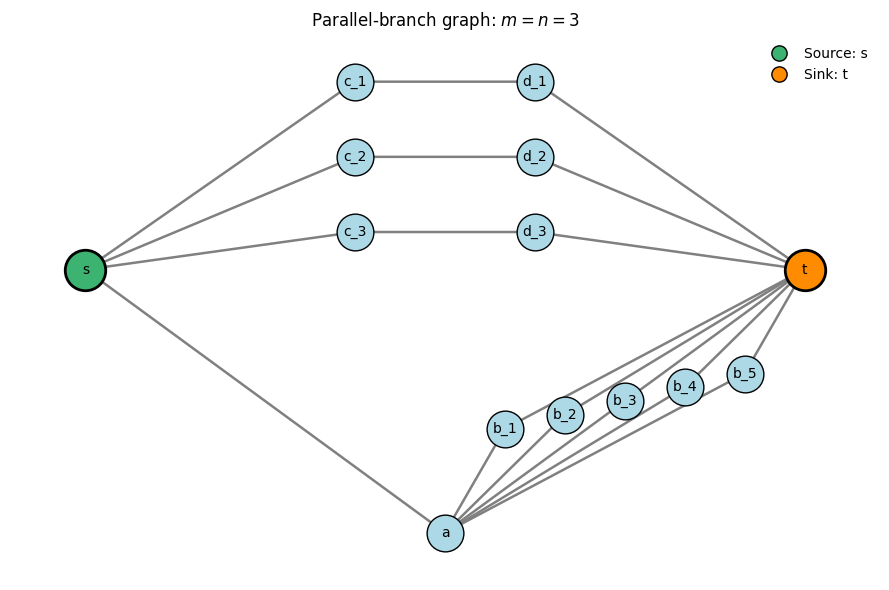

In [95]:
fig, ax = plt.subplots(figsize=(9, 6))

draw_graph(
    branch_graph,
    source=s,
    target=t,
    positions=positions,
    ax=ax,
    title=r"Parallel-branch graph: $m=n=3$",
)

plt.tight_layout()
plt.show()

In [96]:
branch_bp = estimate_bp_corr2(
    branch_graph,
    source=s,
    target=t,
    n_samples=2_000,
    seed=10,
)

branch_exact = exact_corr2_matrix(
    branch_graph,
    source=s,
    target=t,
)

branch_percolation = estimate_percolation_bound(
    branch_graph,
    source=s,
    target=t,
    n_samples=1_000,
    seed=11,
)

print(
    f"BP Corr^2:          "
    f"{branch_bp['corr2']:.6f} "
    f"± {2 * branch_bp['standard_error']:.6f}"
)

print(
    f"Exact Corr^2:       "
    f"{branch_exact['corr2']:.6f}"
)

print(
    f"Percolation bound: "
    f"{branch_percolation['bound']:.6f} "
    f"± {2 * branch_percolation['standard_error']:.6f}"
)

print(
    f"Matrix size:        "
    f"{branch_exact['matrix_size']}"
)

BP Corr^2:          0.207007 ± 0.032882
Exact Corr^2:       0.255854
Percolation bound: 0.269000 ± 0.028046
Matrix size:        128


### Grid Examples

In [111]:
def make_grid(side=5, p=0.1, rng=None):
    """
    Construct a side x side grid with homogeneous flip probability p.

    Returns
    -------
    graph
    source
    target
    observations : one +/-1 observation per edge
    positions     : plotting positions
    """
    if side < 2:
        raise ValueError("side must be at least 2")

    if rng is None:
        rng = np.random.default_rng()

    graph = Graph()
    observations = []
    positions = {}

    middle_row = side // 2

    def node(row, col):
        if row == middle_row and col == 0:
            return "s"
        if row == middle_row and col == side - 1:
            return "t"
        return f"v_{row}_{col}"

    for row in range(side):
        for col in range(side):
            u = node(row, col)
            positions[u] = (col, -row)

            if row > 0:
                v = node(row - 1, col)
                graph.add_edge(v, u, p)
                observations.append(
                    -1 if rng.random() < p else 1
                )

            if col > 0:
                v = node(row, col - 1)
                graph.add_edge(v, u, p)
                observations.append(
                    -1 if rng.random() < p else 1
                )

    return (
        graph,
        "s",
        "t",
        np.asarray(observations, dtype=int),
        positions,
    )

In [141]:
side = 10
p = 0.11


graph, source, target, _, _ = make_grid(
    side=side,
    p=p,
    rng=np.random.default_rng(1),
)

In [142]:
bp_corr_grid = estimate_bp_corr2(
    graph,
    source,
    target,
    n_samples=200,
    seed=0,
)

percolation_grid = estimate_percolation_bound(
    graph,
    source,
    target,
    n_samples=5000,
    seed=2,
)

# print(f"BP Corr²:               {bp_corr['corr2']:.4f}")
# print(f"Percolation upper bound:{upper_bound: .4f}")
# print(f"BP convergence rate:    {bp_corr['convergence_rate']:.4f}")
# print(f"Percolation s.e.:       {upper_se:.4f}")

In [143]:
print(f"BP Corr²:               {bp_corr_grid['corr2']:.4f}")
print(f"Percolation upper bound:{percolation_grid['bound']: .4f}")

BP Corr²:               0.1457
Percolation upper bound: 0.6350
